<a id="top"></a> 
# Text Analysis Assessment Harry Potter Reviews

# Table of Contents 
1. [Business Understanding](#business-understanding) 
2. [Data Understanding](#data-understanding) 
3. [Baseline-Models](#baseline-models) 
4. [Data Preparation](#data-preparation) 
5. [Hyperparameter Tuning](#hyperparameter-tuning) 
6. [Evaluation](#evaluation) 
7. [References](#references) 
8. [Appendix](#appendix) 
<h2 id ="business-understanding">Business Understanding</h2> 
<a href="#top">Back to top</a>

<h2 id = "introduction">Introduction</h2>
<a href="#top">Back to top</a>
This is a text mining analysis of a Harry Potter Review dataset using Python. The notebook is structured in line with the CRISP-DM methodology. The main aim of the project is to classify unstructured review text into two sentiment categories. The written review comments are transformed into numerical feature representations and evaluated using multiple text mining techniques.

<h2 id="business-understanding">Business Understanding</h2>
<a href="#top">Back to top</a>

<h3 id="business-objective">Business Objective</h3>
<a href="#top">Back to top</a>

The objective of this project is to mine unstructured text data and build a text classification pipeline capable of telling the difference between positive and negative review sentiment.

<h3 id="project-aim">Project Aim</h3>
<a href="#top">Back to top</a>
The projects aim is to compare three baseline vectorisation techniques, apply a suitable clasification algorithm, explore the text through statistics and visualisations and iteratively improve performance through preprocessing, feature selection and hyperamerer tuning.

<h3 id="success-criteria">Success Criteria</h3>
<a href="#top">Back to top</a>
As sucessful outcome is a final text mining pipeline that produces strong and consistant cross-validation performance,that is supported by findings from data understanding and preparation.


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import warnings

from sklearn.svm import SVC
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

import text_mining_utils as tmu

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

<h2 id="data-understanding">Data Understanding</h2>
<a href="#top">Back to top</a>

<h3 id="dataset-description">Dataset Description</h3>
<a href="#top">Back to top</a>
The dataset used in this analysis is a CSV file containing Harry Potter review data. The main text field is the (comment) column, which contains the unstructured review text. The (rating) column is used to derive binary class labels for the classification task.

<h3 id="initial-inspection">Initial Inspection</h3>
<a href="#top">Back to top</a>

The dataset is first loaded and inspected to identify its dimensions, available attributes, missing values, and general suitability for text mining.


In [45]:
data = pd.read_csv('HPotterReviews.csv')
print("Shape:", data.shape)

Shape: (491, 8)


In [46]:

print(data.head(5))
print(data.tail(10))
print(data.info)


   user_id user_sex  user_age user_country  rating  \
0        0   female        50      Germany     2.5   
1        1   female        23        Spain     4.0   
2        2     male        32       France     3.0   
3        3   female        24       Turkey     4.5   
4        4   female        40        Spain     5.0   

                                             comment favourite_character  \
0  "The transitions between scenes were awkward, ...       Severus Snape   
1   "Severus Snape's role adds an intriguing layer."       Severus Snape   
2  "The pacing was a bit slow, but the characters...         Ron Weasley   
3  "Hagrid's love for magical creatures is heartw...       Rubeus Hagrid   
4   "Neville Longbottom's courage is awe-inspiring."  Neville Longbottom   

         date  
0  27/12/2004  
1  22/11/2003  
2  16/09/2005  
3  17/09/2002  
4  17/10/2004  
     user_id user_sex  user_age user_country  rating  \
481      481     male        23       Sweden     4.5   
482      4

In [47]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Shape: (491, 8)

Columns:
['user_id', 'user_sex', 'user_age', 'user_country', 'rating', 'comment', 'favourite_character', 'date']


In [48]:
data.isnull().sum()

user_id                0
user_sex               0
user_age               0
user_country           0
rating                 0
comment                0
favourite_character    0
date                   0
dtype: int64

In [49]:
duplicate_count = data.duplicated(subset=['comment']).sum()
print("Duplicate comments:", duplicate_count)

Duplicate comments: 57


In [50]:
data = data.dropna(subset=['comment', 'rating'])
data = data.drop_duplicates(subset=['comment']).reset_index(drop=True)

print("Shape after removing missing values and duplicates:", data.shape)

Shape after removing missing values and duplicates: (434, 8)


<h3 id="label-creation">Label Creation</h3>
<a href="#top">Back to top</a>

To simplify the classification task, I created a binary sentiment label from the review rating. Reviews with a rating below 3.5 are labelled as negative, while reviews with a rating of 3.5 or above are labelled as positive. 

In [51]:
def make_label(rating):
    if rating >= 3.5:
        return "positive"
    else:
        return "negative"

data["label"] = data["rating"].apply(make_label)

data[["rating", "label"]].head()

,rating,label
0,2.5,negative
1,4.0,positive
2,3.0,negative
3,4.5,positive
4,5.0,positive


In [52]:
data["label"].value_counts()

label
positive    350
negative     84
Name: count, dtype: int64

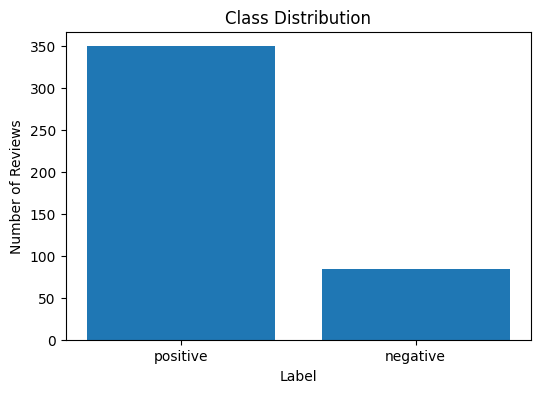

In [53]:
label_counts = data["label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")
plt.show()